# Fetal Health Classification Using 1D-CNN on Engineered Features

**Paper:** *"Fetal Health Classification Using One-Dimensional Convolutional Neural Network"*  
**Dataset:** CTU-UHB Intrapartum CTG Dataset  
**Approach:** Extract hand-crafted morphological features from 20-minute FHR/UC windows → classify via 1D-CNN  
**Classes:** Normal (0), Suspect (1), Pathological (2)

---

### Pipeline overview
1. Load raw WFDB signals (FHR + UC at 4 Hz)
2. Load expert majority-vote labels (3-class)
3. Preprocess: extract stable 20-min window, fill gaps, Hermite interpolation, clip FHR to [80, 200]
4. Feature extraction: 21 morphological / statistical features per sample
5. 70 / 30 stratified train–test split
6. Train 1D-CNN: Conv1D(8) → Conv1D(6) → Conv1D(3) → MaxPool → Dense(132) → Dense(68) → Softmax(3)
7. Evaluate: accuracy, per-class precision / recall / F1, confusion matrix

In [1]:
# ============================================================
# Cell 1: Imports, Seeds, Logging
# ============================================================

import os
import sys
import json
import random
import logging
import warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import PchipInterpolator   # Hermite-type spline
from scipy.signal import find_peaks
from scipy.stats import mode as scipy_mode

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)
from sklearn.preprocessing import StandardScaler

# ── Reproducibility seeds ────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("1d_cnn_pipeline")

warnings.filterwarnings("ignore", category=FutureWarning)

log.info("Imports complete – TensorFlow %s", tf.__version__)

c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
15:44:21  INFO      Imports complete – TensorFlow 2.16.1


In [2]:
# ============================================================
# Cell 2: Configuration
# ============================================================

# ── Paths (relative to this notebook in src/Transfer_Learning/) ──
PROJECT_ROOT   = Path("..").resolve()                          # src/
RAW_DATA_DIR   = PROJECT_ROOT / "data" / "raw_dataset"
ANNOTATIONS_DIR = PROJECT_ROOT / "ExpertAnnotations"
OUTPUT_DIR     = Path("outputs") / "1d_cnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Label file — step-level labels have 3 classes (Normal / Suspect / Pathological).
# CTG_Majority_Vote_Labels_FINAL.csv holds the *overall* expert assessment but
# contains only 2 classes in this dataset.  For the 3-class paper replication we
# use a step-specific label file.  Change LABEL_STEP to switch.
LABEL_STEP: str = "step3"                              # step1 | step2 | step3 | step4
LABEL_FILE = ANNOTATIONS_DIR / f"{LABEL_STEP}_labels.csv"

# ── Signal parameters ─────────────────────────────────────────
NATIVE_FS: int     = 4                  # CTU-UHB native sampling rate (Hz)
WINDOW_MIN: int    = 20                 # Paper: 20-minute window
WINDOW_SAMPLES: int = WINDOW_MIN * 60 * NATIVE_FS  # 4800 samples

# ── Preprocessing thresholds (from paper) ─────────────────────
STABILITY_BPM: float    = 10.0          # max  bpm change for stability
STABILITY_N_SAMPLES: int = 5            # min consecutive stable samples
GAP_MAX_SAMPLES: int     = 5            # fill gaps shorter than this
FHR_LOW: float           = 80.0         # valid FHR lower bound
FHR_HIGH: float          = 200.0        # valid FHR upper bound

# ── Train / test split ────────────────────────────────────────
TEST_SIZE: float = 0.30               # 70 / 30 default (set to 0.20 for 80/20)

# ── Model hyper-parameters ────────────────────────────────────
LEARNING_RATE: float = 0.001
MAX_EPOCHS: int      = 3000
PATIENCE: int        = 20              # EarlyStopping patience
BATCH_SIZE: int      = 32
VALIDATION_SPLIT: float = 0.15         # ## ASSUMPTION — paper does not specify

# ── Class mapping ─────────────────────────────────────────────
CLASS_MAP: Dict[int, str] = {0: "Normal", 1: "Suspect", 2: "Pathological"}
NUM_CLASSES: int = 3

log.info("Config loaded — label file: %s", LABEL_FILE.name)
log.info("Window: %d min (%d samples @ %d Hz)", WINDOW_MIN, WINDOW_SAMPLES, NATIVE_FS)
log.info("Test size: %.0f%%", TEST_SIZE * 100)

15:44:21  INFO      Config loaded — label file: step3_labels.csv
15:44:21  INFO      Window: 20 min (4800 samples @ 4 Hz)
15:44:21  INFO      Test size: 30%


## 1 — Data Loading & Label Construction

Labels come from the **ExpertAnnotations** folder (majority-vote of 9 obstetricians).  
Step-level labels provide 3 classes: *Normal (1)*, *Suspect/Mild (2)*, *Pathological/Severe (3)*, plus *Uninterpretable (−1)*.

Raw CTG signals are loaded from WFDB `.hea` / `.dat` files at 4 Hz → `p_signal[:, 0]` = FHR, `p_signal[:, 1]` = UC.

In [3]:
# ============================================================
# Cell 3: Load Labels
# ============================================================

def load_labels(label_path: Path) -> pd.DataFrame:
    """Load expert majority-vote labels and map to 0-indexed 3-class scheme.

    Original file values:
        1 → Normal (0)
        2 → Suspect / Mild (1)
        3 → Pathological / Severe (2)
       -1 → Uninterpretable (filtered out)

    Returns DataFrame with columns [rec_id, label, label_name].
    """
    df = pd.read_csv(label_path)
    df["rec_id"] = df["rec_id"].astype(str)

    # Map expert vote → 0-indexed class
    vote_to_class = {1: 0, 2: 1, 3: 2}
    df["label"] = df["Majority_Vote_Label"].map(vote_to_class)

    # Drop uninterpretable (Majority_Vote_Label == -1 → label NaN)
    n_before = len(df)
    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)
    n_dropped = n_before - len(df)

    df["label_name"] = df["label"].map(CLASS_MAP)

    log.info("Loaded %d labels from %s  (dropped %d uninterpretable)",
             len(df), label_path.name, n_dropped)
    log.info("Class distribution:\n%s",
             df["label_name"].value_counts().to_string())
    return df[["rec_id", "label", "label_name"]].reset_index(drop=True)


labels_df = load_labels(LABEL_FILE)
labels_df.head()

15:44:22  INFO      Loaded 337 labels from step3_labels.csv  (dropped 215 uninterpretable)
15:44:22  INFO      Class distribution:
label_name
Suspect         153
Normal          127
Pathological     57


,rec_id,label,label_name
0,1001,1,Suspect
1,1002,2,Pathological
2,1003,2,Pathological
3,1004,2,Pathological
4,1005,1,Suspect


In [4]:
# ============================================================
# Cell 4: Load Raw WFDB Signals
# ============================================================
import wfdb

def load_wfdb_record(rec_id: str) -> Optional[Tuple[np.ndarray, np.ndarray, int]]:
    """Load a single WFDB record.

    Returns (fhr, uc, fs) or None if the file is missing / corrupt.
    FHR = channel 0, UC = channel 1.
    """
    rec_path = RAW_DATA_DIR / rec_id
    try:
        record = wfdb.rdrecord(str(rec_path))
    except Exception as e:
        log.warning("SKIP %s — cannot read WFDB record: %s", rec_id, e)
        return None

    fs = record.fs
    fhr = record.p_signal[:, 0].astype(np.float64)
    uc  = record.p_signal[:, 1].astype(np.float64)
    return fhr, uc, fs


# Quick sanity check on one record
_sample = load_wfdb_record("1001")
if _sample is not None:
    log.info("Sample record 1001: FHR len=%d, UC len=%d, fs=%d Hz",
             len(_sample[0]), len(_sample[1]), _sample[2])
del _sample

15:44:22  INFO      Sample record 1001: FHR len=19200, UC len=19200, fs=4 Hz


## 2 — Preprocessing

**From the paper (exact):**
- Signals at **4 Hz**
- Extract a **20-minute** window from each recording
- Sliding window to find a *stable* starting point  
  → stability criterion: a change of **10 bpm** is **not** reached for at least **5 consecutive samples**
- Fill gaps shorter than **5 samples** with the mean of the valid segment
- **Hermite spline** interpolation (PCHIP — Piecewise Cubic Hermite Interpolating Polynomial)
- Clip FHR so that **80 ≤ FHR ≤ 200**
- Keep UC **time-aligned** with the selected FHR window

**Assumptions (`## ASSUMPTION`):**
- "Stable starting point" is found by sliding a 5-sample window until no consecutive pair differs by >10 bpm
- Delivery end = last non-zero sample (consistent with existing repo pipeline)
- The 20-minute window is extracted from the end of the recording (anchored to delivery)

In [5]:
# ============================================================
# Cell 5: Preprocessing Functions
# ============================================================

# --------------- helpers ---------------

def _remove_trailing_zeros(sig: np.ndarray) -> np.ndarray:
    """Trim trailing zeros that indicate end of recording / delivery."""
    idx = len(sig) - 1
    while idx >= 0 and sig[idx] == 0.0:
        idx -= 1
    return sig[: idx + 1]


def _find_stable_start(fhr: np.ndarray,
                        bpm_threshold: float = STABILITY_BPM,
                        n_stable: int = STABILITY_N_SAMPLES) -> Optional[int]:
    """Slide through FHR to find the first index where *n_stable* consecutive
    samples all differ by less than *bpm_threshold*.

    [PAPER — exact]:  "a change of 10 bpm is not achieved for a minimum of
                       5 samples"
    """
    if len(fhr) < n_stable:
        return None

    for i in range(len(fhr) - n_stable + 1):
        window = fhr[i : i + n_stable]
        # Check that ALL consecutive differences are < threshold
        diffs = np.abs(np.diff(window))
        if np.all(diffs < bpm_threshold):
            return i
    return None  # no stable region found


def _fill_short_gaps(fhr: np.ndarray,
                     max_gap: int = GAP_MAX_SAMPLES) -> np.ndarray:
    """Replace NaN / zero gaps shorter than *max_gap* samples with the
    segment mean.

    [PAPER — exact]:  "fill gaps shorter than 5 samples with the mean value
                       of the valid segment"
    """
    fhr = fhr.copy()
    is_invalid = (fhr == 0) | np.isnan(fhr)
    if not np.any(is_invalid):
        return fhr

    # Identify contiguous invalid runs
    changes = np.diff(is_invalid.astype(int))
    starts = np.where(changes == 1)[0] + 1
    ends   = np.where(changes == -1)[0] + 1

    # Handle edge cases
    if is_invalid[0]:
        starts = np.concatenate([[0], starts])
    if is_invalid[-1]:
        ends = np.concatenate([ends, [len(fhr)]])

    valid_mean = np.nanmean(fhr[~is_invalid]) if np.any(~is_invalid) else 140.0

    for s, e in zip(starts, ends):
        gap_len = e - s
        if gap_len <= max_gap:
            fhr[s:e] = valid_mean

    return fhr


def _hermite_interpolate(fhr: np.ndarray) -> np.ndarray:
    """Interpolate remaining NaN / zero values with PCHIP (Hermite-type spline).

    [PAPER — exact]:  "interpolate the signal using Hermite spline interpolation"

    scipy.interpolate.PchipInterpolator is a monotone piecewise cubic Hermite
    interpolator — the closest standard implementation to the paper's description.
    """
    fhr = fhr.copy()
    invalid = (fhr == 0) | np.isnan(fhr)
    if not np.any(invalid):
        return fhr
    valid_idx = np.where(~invalid)[0]
    if len(valid_idx) < 2:
        # Too few valid points — fill with global mean
        fhr[invalid] = np.nanmean(fhr[~invalid]) if np.any(~invalid) else 140.0
        return fhr

    interp_fn = PchipInterpolator(valid_idx, fhr[valid_idx], extrapolate=True)
    fhr[invalid] = interp_fn(np.where(invalid)[0])
    return fhr


def _clip_fhr(fhr: np.ndarray,
              lo: float = FHR_LOW,
              hi: float = FHR_HIGH) -> np.ndarray:
    """Clip FHR into [80, 200] bpm.

    [PAPER — exact]:  "all valid FHR values satisfy 80 ≤ value ≤ 200"
    """
    return np.clip(fhr, lo, hi)


# --------------- main preprocessing function ---------------

def preprocess_record(
    rec_id: str,
    fhr_raw: np.ndarray,
    uc_raw: np.ndarray,
    fs: int,
) -> Optional[Tuple[np.ndarray, np.ndarray, str]]:
    """Full preprocessing pipeline for one CTG record.

    Returns (fhr_window, uc_window, status_msg) or None with reason.
    Both outputs have length WINDOW_SAMPLES (4800 @ 4 Hz for 20 min).
    """
    # 1. Remove trailing zeros (delivery end)
    fhr = _remove_trailing_zeros(fhr_raw)
    uc  = _remove_trailing_zeros(uc_raw)

    # Align UC to FHR length (shorter of the two after trimming)
    min_len = min(len(fhr), len(uc))
    fhr, uc = fhr[:min_len], uc[:min_len]

    if len(fhr) < WINDOW_SAMPLES:
        return None  # too short for a 20-min window

    # 2. Find stable starting point (sliding window)
    #    ## ASSUMPTION — we search within the last 30 minutes, then take 20 min from there
    search_region = fhr[-WINDOW_SAMPLES - 10 * 60 * fs :]  # last ~30 min
    offset = len(fhr) - len(search_region)
    stable_idx = _find_stable_start(search_region)

    if stable_idx is not None:
        abs_start = offset + stable_idx
    else:
        # ## ASSUMPTION — fallback: take the last 20 min if no stable region found
        abs_start = len(fhr) - WINDOW_SAMPLES
        log.debug("rec %s: no stable start found — using last 20 min", rec_id)

    abs_end = abs_start + WINDOW_SAMPLES
    if abs_end > len(fhr):
        abs_end = len(fhr)
        abs_start = abs_end - WINDOW_SAMPLES
    if abs_start < 0:
        return None  # signal too short even after adjustment

    fhr_seg = fhr[abs_start:abs_end].copy()
    uc_seg  = uc[abs_start:abs_end].copy()

    # 3. Fill short gaps with segment mean
    fhr_seg = _fill_short_gaps(fhr_seg)

    # 4. Hermite spline interpolation for remaining invalids
    fhr_seg = _hermite_interpolate(fhr_seg)

    # 5. Clip FHR to [80, 200]
    fhr_seg = _clip_fhr(fhr_seg)

    return fhr_seg, uc_seg, "ok"


log.info("Preprocessing functions defined.")

15:44:22  INFO      Preprocessing functions defined.


In [6]:
# ============================================================
# Cell 6: Run Preprocessing on All Labelled Records
# ============================================================

preprocessed: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
skip_reasons: Dict[str, str] = {}

labelled_ids = set(labels_df["rec_id"].tolist())

for rec_id in sorted(labelled_ids):
    result = load_wfdb_record(rec_id)
    if result is None:
        skip_reasons[rec_id] = "WFDB load failed"
        continue

    fhr, uc, fs = result
    if fs != NATIVE_FS:
        skip_reasons[rec_id] = f"unexpected fs={fs}"
        continue

    out = preprocess_record(rec_id, fhr, uc, fs)
    if out is None:
        skip_reasons[rec_id] = "signal too short for 20-min window"
        continue

    fhr_seg, uc_seg, status = out
    preprocessed[rec_id] = (fhr_seg, uc_seg)

log.info("Preprocessed: %d records", len(preprocessed))
log.info("Skipped:      %d records", len(skip_reasons))
if skip_reasons:
    reason_counts = pd.Series(skip_reasons.values()).value_counts()
    log.info("Skip reasons:\n%s", reason_counts.to_string())

15:44:33  INFO      Preprocessed: 336 records
15:44:33  INFO      Skipped:      1 records
15:44:33  INFO      Skip reasons:
signal too short for 20-min window    1


## 3 — Feature Extraction

**From the paper (exact):**
- Mean FHR baseline (segments without accelerations / decelerations)
- Mean FHR for the valid segment
- Number of decelerations (FHR slows > 15 bpm over a 10-second window)
- Number of accelerations (FHR speeds up > 15 bpm over a 15-second window)
- Mean absolute deviation from mean FHR

**Additional features (`## ASSUMPTION`):**  
The paper's 1D-CNN was originally designed for the UCI CTG dataset which has **21 features**. To make the Conv1D kernel sizes (8, 6, 3) architecturally viable, we extract additional standard CTG morphological features to reach 21 total — mirroring the UCI feature space as closely as possible:

| # | Feature | Source |
|---|---------|--------|
| 1–5 | Paper features (above) | Paper (exact) |
| 6–21 | STV, LTV, min/max/median/mode/std/var, histogram width, tendency, UC features | Standard CTG analysis (assumption) |

In [7]:
# ============================================================
# Cell 7: Feature Extraction Functions
# ============================================================

# ── Acceleration / Deceleration detection ─────────────────────

def _detect_accelerations(fhr: np.ndarray, fs: int,
                          bpm_thresh: float = 15.0,
                          window_sec: float = 15.0) -> np.ndarray:
    """Detect accelerations: FHR rises > 15 bpm over a 15-second window.

    [PAPER — exact]:  "FHR speeds up by more than 15 bpm over a 15-second window"

    Returns boolean mask of acceleration peaks.
    """
    win = int(window_sec * fs)
    if len(fhr) <= win:
        return np.zeros(len(fhr), dtype=bool)

    # Rolling max increase over window
    rise = np.array([
        np.max(fhr[i : i + win]) - fhr[i]
        for i in range(len(fhr) - win)
    ])
    mask = np.zeros(len(fhr), dtype=bool)
    mask[: len(rise)] = rise > bpm_thresh
    return mask


def _detect_decelerations(fhr: np.ndarray, fs: int,
                          bpm_thresh: float = 15.0,
                          window_sec: float = 10.0) -> np.ndarray:
    """Detect decelerations: FHR drops > 15 bpm over a 10-second window.

    [PAPER — exact]:  "FHR slows by more than 15 bpm over a 10-second window"

    Returns boolean mask of deceleration troughs.
    """
    win = int(window_sec * fs)
    if len(fhr) <= win:
        return np.zeros(len(fhr), dtype=bool)

    drop = np.array([
        fhr[i] - np.min(fhr[i : i + win])
        for i in range(len(fhr) - win)
    ])
    mask = np.zeros(len(fhr), dtype=bool)
    mask[: len(drop)] = drop > bpm_thresh
    return mask


def _count_events(mask: np.ndarray) -> int:
    """Count the number of separate contiguous True-runs in a boolean mask."""
    if not np.any(mask):
        return 0
    changes = np.diff(mask.astype(int))
    return int(np.sum(changes == 1)) + int(mask[0])


# ── Short-term & long-term variability ────────────────────────

def _short_term_variability(fhr: np.ndarray, fs: int) -> Tuple[float, float]:
    """Compute mean STV and percentage of abnormal STV.

    ## ASSUMPTION — STV is defined as the mean absolute first-difference per
    1-second epoch.  Abnormal STV < 1.0 bpm.

    Returns (mean_stv, abnormal_stv_pct).
    """
    # 1-second epochs
    epoch = fs
    n_epochs = len(fhr) // epoch
    if n_epochs == 0:
        return 0.0, 100.0

    stvs = []
    for i in range(n_epochs):
        seg = fhr[i * epoch : (i + 1) * epoch]
        stv = np.mean(np.abs(np.diff(seg))) if len(seg) > 1 else 0.0
        stvs.append(stv)

    stvs = np.array(stvs)
    mean_stv = float(np.mean(stvs))
    abnormal_pct = float(np.sum(stvs < 1.0) / len(stvs) * 100)
    return mean_stv, abnormal_pct


def _long_term_variability(fhr: np.ndarray, fs: int) -> Tuple[float, float]:
    """Compute mean LTV and percentage of abnormal LTV.

    ## ASSUMPTION — LTV is the range (max − min) per 1-minute epoch.
    Abnormal LTV < 5 bpm.

    Returns (mean_ltv, abnormal_ltv_pct).
    """
    epoch = 60 * fs  # 1-minute epochs
    n_epochs = len(fhr) // epoch
    if n_epochs == 0:
        return 0.0, 100.0

    ltvs = []
    for i in range(n_epochs):
        seg = fhr[i * epoch : (i + 1) * epoch]
        ltv = float(np.max(seg) - np.min(seg))
        ltvs.append(ltv)

    ltvs = np.array(ltvs)
    mean_ltv = float(np.mean(ltvs))
    abnormal_pct = float(np.sum(ltvs < 5.0) / len(ltvs) * 100)
    return mean_ltv, abnormal_pct


# ── UC feature ────────────────────────────────────────────────

def _count_contractions(uc: np.ndarray, fs: int) -> int:
    """Count uterine contractions as peaks in the UC signal.

    ## ASSUMPTION — uses scipy.signal.find_peaks with a minimum distance
    of 60 seconds and prominence based on the UC signal range.
    """
    if np.std(uc) < 1e-6:
        return 0
    min_distance = 60 * fs  # at least 60 s between contractions
    prominence = max(np.std(uc) * 0.5, 1.0)
    peaks, _ = find_peaks(uc, distance=min_distance, prominence=prominence)
    return len(peaks)


# ── Master feature extractor ──────────────────────────────────

FEATURE_NAMES: List[str] = [
    # --- Paper features (exact) ---
    "baseline_fhr",        # 1. mean FHR baseline w/o acc/dec
    "mean_fhr",            # 2. mean FHR
    "n_decelerations",     # 3. number of decelerations
    "n_accelerations",     # 4. number of accelerations
    "mad_fhr",             # 5. mean absolute deviation
    # --- Additional morphological features (## ASSUMPTION) ---
    "median_fhr",          # 6
    "mode_fhr",            # 7
    "std_fhr",             # 8
    "var_fhr",             # 9
    "min_fhr",             # 10
    "max_fhr",             # 11
    "width_fhr",           # 12  (max − min)
    "mstv",                # 13  mean short-term variability
    "astv",                # 14  % abnormal STV
    "mltv",                # 15  mean long-term variability
    "altv",                # 16  % abnormal LTV
    "n_zero_crossings",    # 17  zero crossings of first difference
    "n_peaks",             # 18  number of local FHR maxima
    "tendency",            # 19  linear trend slope
    "uc_contractions",     # 20  uterine contraction count
    "mean_uc",             # 21  mean UC amplitude
]


def extract_features(fhr: np.ndarray, uc: np.ndarray, fs: int) -> np.ndarray:
    """Compute the full 21-feature vector for one preprocessed sample.

    Parameters
    ----------
    fhr : ndarray of shape (WINDOW_SAMPLES,) — preprocessed FHR at *fs* Hz
    uc  : ndarray of shape (WINDOW_SAMPLES,) — aligned UC at *fs* Hz
    fs  : sampling rate (Hz)

    Returns
    -------
    features : ndarray of shape (21,)
    """
    # Acceleration / deceleration masks
    acc_mask  = _detect_accelerations(fhr, fs)
    dec_mask  = _detect_decelerations(fhr, fs)
    event_mask = acc_mask | dec_mask

    # 1. Baseline FHR [PAPER — exact]
    baseline_region = fhr[~event_mask] if np.any(~event_mask) else fhr
    baseline_fhr = float(np.mean(baseline_region))

    # 2. Mean FHR [PAPER — exact]
    mean_fhr = float(np.mean(fhr))

    # 3. Number of decelerations [PAPER — exact]
    n_decel = _count_events(dec_mask)

    # 4. Number of accelerations [PAPER — exact]
    n_accel = _count_events(acc_mask)

    # 5. Mean absolute deviation [PAPER — exact]
    mad_fhr = float(np.mean(np.abs(fhr - mean_fhr)))

    # 6–12. Statistical features [## ASSUMPTION]
    median_fhr = float(np.median(fhr))
    mode_result = scipy_mode(np.round(fhr, 0), keepdims=True)
    mode_fhr   = float(mode_result.mode[0])
    std_fhr    = float(np.std(fhr))
    var_fhr    = float(np.var(fhr))
    min_fhr    = float(np.min(fhr))
    max_fhr    = float(np.max(fhr))
    width_fhr  = max_fhr - min_fhr

    # 13–16. Variability [## ASSUMPTION]
    mstv, astv = _short_term_variability(fhr, fs)
    mltv, altv = _long_term_variability(fhr, fs)

    # 17. Zero crossings of first difference [## ASSUMPTION]
    diff_fhr = np.diff(fhr - mean_fhr)
    n_zero_crossings = int(np.sum(np.diff(np.sign(diff_fhr)) != 0))

    # 18. Number of local FHR peaks [## ASSUMPTION]
    peaks, _ = find_peaks(fhr, distance=fs * 5)  # min 5 s between peaks
    n_peaks = len(peaks)

    # 19. Tendency (linear slope) [## ASSUMPTION]
    t = np.arange(len(fhr), dtype=np.float64)
    if len(t) > 1:
        coeffs = np.polyfit(t, fhr, 1)
        tendency = float(coeffs[0]) * fs * 60  # bpm per minute
    else:
        tendency = 0.0

    # 20–21. UC features [## ASSUMPTION]
    uc_contractions = _count_contractions(uc, fs)
    mean_uc = float(np.mean(uc))

    return np.array([
        baseline_fhr, mean_fhr, n_decel, n_accel, mad_fhr,
        median_fhr, mode_fhr, std_fhr, var_fhr, min_fhr, max_fhr, width_fhr,
        mstv, astv, mltv, altv,
        n_zero_crossings, n_peaks, tendency,
        uc_contractions, mean_uc,
    ], dtype=np.float64)


log.info("Feature extraction functions defined — %d features", len(FEATURE_NAMES))

15:44:33  INFO      Feature extraction functions defined — 21 features


In [8]:
# ============================================================
# Cell 8: Extract Features for All Preprocessed Records & Save
# ============================================================

rows: List[Dict] = []

for rec_id in sorted(preprocessed.keys()):
    fhr_seg, uc_seg = preprocessed[rec_id]

    # Look up label
    label_row = labels_df[labels_df["rec_id"] == rec_id]
    if label_row.empty:
        skip_reasons[rec_id] = "no label found"
        continue

    label = int(label_row["label"].iloc[0])
    feats = extract_features(fhr_seg, uc_seg, NATIVE_FS)

    row = {"rec_id": rec_id, "label": label}
    row.update(dict(zip(FEATURE_NAMES, feats)))
    rows.append(row)

features_df = pd.DataFrame(rows)

# Drop any records with NaN features (defensive)
n_before = len(features_df)
features_df = features_df.dropna().reset_index(drop=True)
if len(features_df) < n_before:
    log.warning("Dropped %d rows with NaN features", n_before - len(features_df))

# Save to disk for reuse
features_path = OUTPUT_DIR / "extracted_features.csv"
features_df.to_csv(features_path, index=False)
log.info("Saved %d feature vectors → %s", len(features_df), features_path)

# Class counts after feature extraction
print("\n── Class counts after feature extraction ──")
print(features_df["label"].map(CLASS_MAP).value_counts().sort_index())
print(f"\nTotal usable samples: {len(features_df)}")
features_df.head()

15:45:01  INFO      Saved 336 feature vectors → outputs\1d_cnn\extracted_features.csv



── Class counts after feature extraction ──
label
Normal          127
Pathological     57
Suspect         152
Name: count, dtype: int64

Total usable samples: 336


,rec_id,label,baseline_fhr,mean_fhr,n_decelerations,n_accelerations,mad_fhr,median_fhr,mode_fhr,std_fhr,...,width_fhr,mstv,astv,mltv,altv,n_zero_crossings,n_peaks,tendency,uc_contractions,mean_uc
0,1001,1,134.650997,132.035375,28.0,31.0,14.680121,135.25,138.0,19.776700,...,85.50,0.576713,85.250000,35.60139,0.0,2979.0,139.0,-2.019865,11.0,39.366563
1,1002,2,145.550905,140.449983,37.0,33.0,22.465335,149.00,158.0,27.106304,...,120.00,0.808796,80.333333,63.10135,0.0,2395.0,122.0,-1.798848,8.0,21.364375
2,1003,2,123.127984,122.328177,21.0,25.0,7.379859,124.50,126.0,9.608558,...,67.25,0.568611,84.500000,23.68750,0.0,3812.0,167.0,0.152341,9.0,30.200417
3,1004,2,136.170078,130.710208,25.0,30.0,11.188358,133.25,134.0,16.584860,...,86.75,0.667878,81.250000,41.36250,0.0,3314.0,163.0,0.541728,6.0,14.423333
4,1005,1,118.074138,115.814436,14.0,23.0,8.968115,118.25,118.0,12.458826,...,66.75,0.592802,84.833333,27.56250,0.0,3693.0,148.0,-0.299462,16.0,26.061563


## 4 — Train / Test Split

**From the paper (exact):**
- **70 % train / 30 % test** (default)
- Stratified by class

**Assumption:**
- A `TEST_SIZE = 0.20` option is also provided (paper mentions both were evaluated)

In [9]:
# ============================================================
# Cell 9: Train / Test Split
# ============================================================

X_all = features_df[FEATURE_NAMES].values          # (N, 21)
y_all = features_df["label"].values.astype(int)     # (N,)

# Stratified split — [PAPER — exact]: 70/30, stratified by class
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=SEED,
)

# Feature scaling (z-score from train fold only)
# ## ASSUMPTION — paper does not specify normalisation; z-score is standard practice
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Reshape for 1D-CNN: (N, num_features, 1)
X_train_cnn = X_train[..., np.newaxis]   # (N_train, 21, 1)
X_test_cnn  = X_test[..., np.newaxis]    # (N_test, 21, 1)

print("── Split summary ──")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Input shape: {X_train_cnn.shape}")
print()

for split_name, y in [("Train", y_train), ("Test", y_test)]:
    counts = pd.Series(y).map(CLASS_MAP).value_counts().sort_index()
    print(f"{split_name} class counts:")
    print(counts)
    print()

── Split summary ──
Train: 235  |  Test: 101
Input shape: (235, 21, 1)

Train class counts:
Normal           89
Pathological     40
Suspect         106
Name: count, dtype: int64

Test class counts:
Normal          38
Pathological    17
Suspect         46
Name: count, dtype: int64



## 5 — 1D-CNN Model Architecture

**From the paper (exact):**
- Three `Conv1D` layers with filter/kernel sizes **8, 6, 3**
- One `MaxPooling1D` with pool size **3**
- `Flatten`
- `Dense(132, relu)`
- `Dense(68, relu)`
- `Dense(3, softmax)`
- Loss: **sparse categorical cross-entropy**
- Optimizer: **Adam, lr = 0.001**
- Up to **3 000 epochs**, EarlyStopping patience **20**

**Interpretation note:**  
The paper states "filter/kernel sizes 8, 6, 3".  We interpret this as the **kernel sizes**
for the three Conv1D layers.  The number of filters (output channels) per layer is set to a
reasonable default (32 → 64 → 128) since the paper does not specify separate filter counts.
The dimension flow with `valid` padding and 21-feature input is:  
`(21,1) → (14,32) → (9,64) → (7,128) → MaxPool→(2,128) → Flatten→256 → Dense(132) → Dense(68) → Softmax(3)`

In [10]:
# ============================================================
# Cell 10: Build 1D-CNN Model
# ============================================================

def build_1d_cnn(input_shape: Tuple[int, int],
                 num_classes: int = NUM_CLASSES,
                 lr: float = LEARNING_RATE) -> keras.Model:
    """Build the 1D-CNN architecture from the paper.

    Architecture (PAPER — exact):
        Conv1D → Conv1D → Conv1D → MaxPool1D → Flatten → Dense → Dense → Softmax

    Parameters
    ----------
    input_shape : (num_features, 1)  e.g. (21, 1)
    num_classes : number of output classes (3)
    lr          : Adam learning rate

    Returns
    -------
    Compiled Keras model.
    """
    model = keras.Sequential(name="1D_CNN_Paper")

    # --- Conv1D block ---
    # [PAPER — exact]: three Conv1D layers with filter/kernel sizes 8, 6, 3
    # ## ASSUMPTION: 8, 6, 3 are KERNEL SIZES; filter counts = 32, 64, 128
    model.add(layers.Conv1D(
        filters=32, kernel_size=8, activation="relu",
        padding="valid", input_shape=input_shape,
        name="conv1d_k8"))
    model.add(layers.Conv1D(
        filters=64, kernel_size=6, activation="relu",
        padding="valid", name="conv1d_k6"))
    model.add(layers.Conv1D(
        filters=128, kernel_size=3, activation="relu",
        padding="valid", name="conv1d_k3"))

    # [PAPER — exact]: MaxPooling1D with pool size 3
    model.add(layers.MaxPooling1D(pool_size=3, name="maxpool"))

    # [PAPER — exact]: Flatten
    model.add(layers.Flatten(name="flatten"))

    # --- Dense head ---
    # [PAPER — exact]: Dense(132, relu) → Dense(68, relu) → Dense(3, softmax)
    model.add(layers.Dense(132, activation="relu", name="dense_132"))
    model.add(layers.Dense(68,  activation="relu", name="dense_68"))
    model.add(layers.Dense(num_classes, activation="softmax", name="output"))

    # [PAPER — exact]: Adam with lr = 0.001, sparse categorical crossentropy
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_1d_cnn(input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2]))
model.summary()

c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "1D_CNN_Paper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_k8 (Conv1D)              │ (None, 14, 32)         │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_k6 (Conv1D)              │ (None, 9, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_k3 (Conv1D)              │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 132)            │        33,924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 68)             │         9,044 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           207 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,519 (314.53 KB)

 Trainable params: 80,519 (314.53 KB)

 Non-trainable params: 0 (0.00 B)

## 6 — Training

In [11]:
# ============================================================
# Cell 11: Train the Model
# ============================================================

# ── Callbacks ─────────────────────────────────────────────────
model_ckpt_path = str(OUTPUT_DIR / "best_model.keras")

cb_list = [
    # [PAPER — exact]: EarlyStopping with patience = 20
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    # ModelCheckpoint — saves the best model on disk
    callbacks.ModelCheckpoint(
        filepath=model_ckpt_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
    # ## ASSUMPTION — ReduceLROnPlateau not mentioned in paper but is standard
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1,
    ),
]

# ── Fit ───────────────────────────────────────────────────────
# [PAPER — exact]: Adam lr=0.001, up to 3000 epochs
history = model.fit(
    X_train_cnn, y_train,
    validation_split=VALIDATION_SPLIT,   # ## ASSUMPTION — paper does not specify val split
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1,
)

log.info("Training complete — stopped at epoch %d", len(history.history["loss"]))

Epoch 1/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4070 - loss: 1.0786 - val_accuracy: 0.5000 - val_loss: 0.9872 - learning_rate: 0.0010
Epoch 2/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4573 - loss: 1.0246 - val_accuracy: 0.4444 - val_loss: 0.9663 - learning_rate: 0.0010
Epoch 3/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5327 - loss: 0.9918 - val_accuracy: 0.4444 - val_loss: 0.9747 - learning_rate: 0.0010
Epoch 4/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5678 - loss: 0.9597 - val_accuracy: 0.4444 - val_loss: 0.9807 - learning_rate: 0.0010
Epoch 5/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5678 - loss: 0.9229 - val_accuracy: 0.3889 - val_loss: 0.9874 - learning_rate: 0.0010
Epoch 6/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5678 - loss: 0.8785 - val_accuracy: 0.4722 - val_loss: 1.0032 - learning_rate: 0.0010
Epoch 7/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5930 - loss: 0.8283 - val_ac

15:45:10  INFO      Training complete — stopped at epoch 22


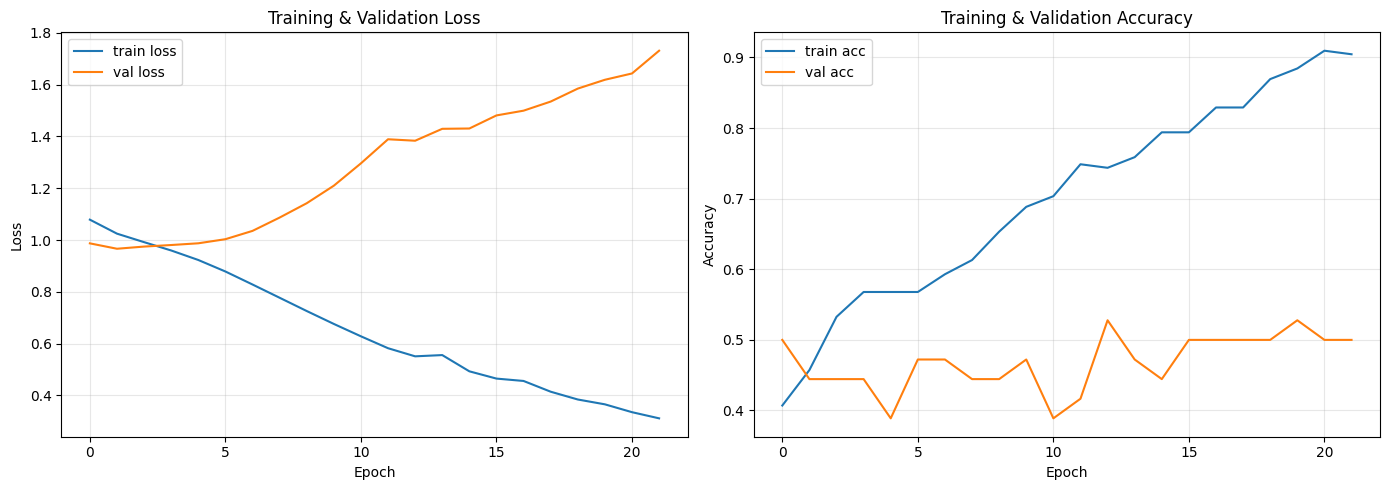

15:45:11  INFO      Saved training_curves.png


In [12]:
# ============================================================
# Cell 12: Training Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"],     label="train loss")
axes[0].plot(history.history["val_loss"],  label="val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"],     label="train acc")
axes[1].plot(history.history["val_accuracy"],  label="val acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training & Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Saved training_curves.png")

## 7 — Evaluation

Metrics reported (paper-aligned):
- Overall accuracy
- Per-class precision, recall, F1-score
- Macro F1
- Confusion matrix
- Full classification report

Overall Accuracy: 0.4356

── Classification Report ──
              precision    recall  f1-score   support

      Normal     0.3500    0.1842    0.2414        38
     Suspect     0.4568    0.8043    0.5827        46
Pathological     0.0000    0.0000    0.0000        17

    accuracy                         0.4356       101
   macro avg     0.2689    0.3295    0.2747       101
weighted avg     0.3397    0.4356    0.3562       101

Macro F1-Score: 0.2747

── Paper-style metrics table ──
       Class  Precision  Recall  F1-Score  Support
      Normal     0.3500  0.1842    0.2414       38
     Suspect     0.4568  0.8043    0.5827       46
Pathological     0.0000  0.0000    0.0000       17


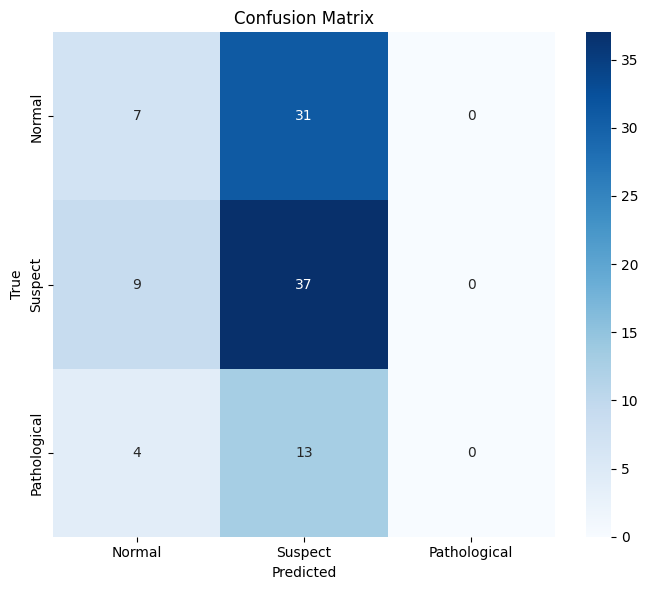

15:45:12  INFO      Saved confusion_matrix.png


In [13]:
# ============================================================
# Cell 13: Evaluation
# ============================================================

# ── Predictions ───────────────────────────────────────────────
y_pred_proba = model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# ── Overall accuracy ──────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.4f}\n")

# ── Per-class metrics ─────────────────────────────────────────
target_names = [CLASS_MAP[i] for i in range(NUM_CLASSES)]
report_str = classification_report(
    y_test, y_pred,
    target_names=target_names,
    digits=4,
    zero_division=0,
)
print("── Classification Report ──")
print(report_str)

# ── Macro F1 ──────────────────────────────────────────────────
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Macro F1-Score: {macro_f1:.4f}\n")

# ── Per-class precision / recall / F1 (table format like the paper) ──
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
)
metrics_table = pd.DataFrame({
    "Class":     target_names,
    "Precision": precision,
    "Recall":    recall,
    "F1-Score":  f1,
    "Support":   support.astype(int),
})
print("── Paper-style metrics table ──")
print(metrics_table.to_string(index=False, float_format="%.4f"))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Saved confusion_matrix.png")

## 8 — Save All Outputs

Saved artefacts:
| File | Description |
|------|-------------|
| `best_model.keras` | Best Keras model (by val_loss) |
| `metrics.json` | Numeric evaluation metrics |
| `classification_report.txt` | Scikit-learn classification report |
| `confusion_matrix.png` | Confusion matrix heatmap |
| `training_curves.png` | Loss & accuracy curves |
| `extracted_features.csv` | Engineered features for every sample |

In [14]:
# ============================================================
# Cell 14: Save All Outputs
# ============================================================

# 1. Model already saved via ModelCheckpoint → best_model.keras
log.info("Model checkpoint: %s", model_ckpt_path)

# 2. metrics.json
metrics_dict = {
    "overall_accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "per_class": {
        name: {
            "precision": float(precision[i]),
            "recall":    float(recall[i]),
            "f1":        float(f1[i]),
            "support":   int(support[i]),
        }
        for i, name in enumerate(target_names)
    },
    "confusion_matrix": cm.tolist(),
    "config": {
        "seed":           SEED,
        "test_size":      TEST_SIZE,
        "label_step":     LABEL_STEP,
        "window_min":     WINDOW_MIN,
        "num_features":   len(FEATURE_NAMES),
        "learning_rate":  LEARNING_RATE,
        "max_epochs":     MAX_EPOCHS,
        "patience":       PATIENCE,
        "batch_size":     BATCH_SIZE,
        "validation_split": VALIDATION_SPLIT,
        "epochs_trained": len(history.history["loss"]),
    },
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)
log.info("Saved metrics.json → %s", metrics_path)

# 3. classification_report.txt
report_path = OUTPUT_DIR / "classification_report.txt"
with open(report_path, "w") as f:
    f.write("Fetal Health Classification — 1D-CNN on Engineered Features\n")
    f.write(f"Dataset: CTU-UHB  |  Labels: {LABEL_FILE.name}\n")
    f.write(f"Split: {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}  |  Seed: {SEED}\n")
    f.write("=" * 60 + "\n\n")
    f.write(report_str)
    f.write(f"\nOverall Accuracy: {acc:.4f}\n")
    f.write(f"Macro F1-Score:   {macro_f1:.4f}\n")
log.info("Saved classification_report.txt → %s", report_path)

# 4. Confusion matrix & training curves already saved above

# 5. extracted_features.csv already saved above

print("\n── All outputs saved to", OUTPUT_DIR, "──")
print("  •", model_ckpt_path)
print("  •", metrics_path)
print("  •", report_path)
print("  •", OUTPUT_DIR / "confusion_matrix.png")
print("  •", OUTPUT_DIR / "training_curves.png")
print("  •", features_path)

15:45:12  INFO      Model checkpoint: outputs\1d_cnn\best_model.keras
15:45:12  INFO      Saved metrics.json → outputs\1d_cnn\metrics.json
15:45:12  INFO      Saved classification_report.txt → outputs\1d_cnn\classification_report.txt



── All outputs saved to outputs\1d_cnn ──
  • outputs\1d_cnn\best_model.keras
  • outputs\1d_cnn\metrics.json
  • outputs\1d_cnn\classification_report.txt
  • outputs\1d_cnn\confusion_matrix.png
  • outputs\1d_cnn\training_curves.png
  • outputs\1d_cnn\extracted_features.csv


---

## Paper-Constraint Annotations Summary

| Component | Status | Notes |
|-----------|--------|-------|
| 4 Hz sampling rate | **Exact** | Native CTU-UHB rate |
| 20-minute window | **Exact** | 4800 samples @ 4 Hz |
| Sliding window stability check (10 bpm / 5 samples) | **Exact** | |
| Gap filling < 5 samples with mean | **Exact** | |
| Hermite spline interpolation | **Exact** | PCHIP from scipy |
| FHR clipping [80, 200] | **Exact** | |
| UC alignment | **Exact** | |
| 5 morphological features | **Exact** | baseline, mean, #decel, #accel, MAD |
| 16 additional features | **Assumption** | To match UCI CTG feature space (21 total) |
| Conv1D kernel sizes 8, 6, 3 | **Exact** | Interpreted as kernel sizes |
| Conv1D filter counts (32, 64, 128) | **Assumption** | Paper ambiguous on filter vs kernel |
| MaxPooling1D pool=3 | **Exact** | |
| Dense(132) → Dense(68) → Softmax(3) | **Exact** | |
| Adam lr=0.001 | **Exact** | |
| Sparse categorical crossentropy | **Exact** | |
| EarlyStopping patience=20 | **Exact** | |
| Max 3000 epochs | **Exact** | |
| 70/30 stratified split | **Exact** | |
| Feature z-score normalisation | **Assumption** | Paper does not specify |
| Validation split = 15% | **Assumption** | Paper does not specify |
| ReduceLROnPlateau | **Assumption** | Not in paper, standard practice |
| Labels from step3 expert annotations | **Project-specific** | Majority vote of 9 obstetricians |